Предмет "Искусственный интеллект"
Лабораторная работа №1

Грибушенков Михаил, группа РФЗ-2-2022

Задание 1: Скачать один из наборов данных.

Датасет про мины в земле и металлоискатель (https://archive.ics.uci.edu/dataset/763/land+mines-1)

1) V - voltage: output voltage value of FLC sensor due to magnetic distortion in V
2) H - the height of the sensor from the ground in	cm
3) S - soil type: 6 different soil types depending on the moisture condition
4) M - mine type: mine types commonly encountered on land (5 different mine classes)

Типы почв: dry and sandy, dry and humus, dry and limy, humid and sandy, humid and humus, humid and limy

Типы мин: Null, Anti-Tank, Anti-personnel, Booby Trapped Anti-personnel, M14 Anti-personnel


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# defines
filename = "Mine_Dataset.xls"

Задание 2: Загрузить данные в датафрейм.

In [4]:
db = pd.read_excel (filename, sheet_name=1) # Загрузка базы данных из файла
db.head(30)

,V,H,S,M
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1
5,0.240966,0.727273,0.0,1
6,0.254410,0.818182,0.0,1
7,0.234924,1.000000,0.0,1
8,0.353474,0.000000,0.6,1
9,0.335347,0.181818,0.6,1


Задание 3: Вывести статистическую информацию о наборе данных.

In [5]:
db.describe()

,V,H,S,M
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


Видно, что данные нормализованы, целевая переменная характеризует один из пяти классов мин, из которых один - не мина, что пропусков в данных нет.

In [7]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V       338 non-null    float64
 1   H       338 non-null    float64
 2   S       338 non-null    float64
 3   M       338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB


Задание 4: Вывести названия столбцов и строк.

In [9]:
print(list(db.index.values)) # Названия строк соответствуют индексам элементов датасета

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), n

In [10]:
print(list(db.columns.values))  # Названия столбцов соответствуют фичам и представлены в описании датасета

['V', 'H', 'S', 'M']


Задание 5.Заменить категориальные данные количественными.

ТАк как таковых в датасете нет, то сначала заменим количественные данные категориальными, а потом наоборот.

Количественные - в категорию...

In [71]:
db_2 = db.copy()
db_2 = db_2.replace (to_replace = {"M": {1: "Не мина", 2: "Противотанковая", 3: "Противопехотная", 4: "Противопехотная мина-ловушка", 5: "Противопехотная М14", 6: "Если такая мина есть, то что-то пошло не так"}})
print (db_2.values.tolist())

[[0.338156758249332, 0.0, 0.0, 'Не мина', Interval(0.2, 0.4, closed='right')], [0.320241334151485, 0.181818181818182, 0.0, 'Не мина', Interval(0.2, 0.4, closed='right')], [0.287008750465028, 0.272727272727273, 0.0, 'Не мина', Interval(0.2, 0.4, closed='right')], [0.256283622072919, 0.454545454545455, 0.0, 'Не мина', Interval(0.2, 0.4, closed='right')], [0.262839598690364, 0.545454545454545, 0.0, 'Не мина', Interval(0.2, 0.4, closed='right')], [0.240966462513951, 0.727272727272727, 0.0, 'Не мина', Interval(0.2, 0.4, closed='right')], [0.25441048592615, 0.818181818181818, 0.0, 'Не мина', Interval(0.2, 0.4, closed='right')], [0.234924174592517, 1.0, 0.0, 'Не мина', Interval(0.2, 0.4, closed='right')], [0.353473917837944, 0.0, 0.6, 'Не мина', Interval(0.2, 0.4, closed='right')], [0.335347053984713, 0.181818181818182, 0.6, 'Не мина', Interval(0.2, 0.4, closed='right')], [0.335347053984713, 0.272727272727273, 0.6, 'Не мина', Interval(0.2, 0.4, closed='right')], [0.330029894425744, 0.45454545

И обратно, для разнообразия - в one hot encoder

In [33]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
result = encoder.fit_transform(db_2[["M"]])
categories = encoder.categories_[0]
print (categories)

['Не мина' 'Противопехотная' 'Противопехотная М14'
 'Противопехотная мина-ловушка' 'Противотанковая']


In [63]:
db_2 [categories] = result.toarray()
db_2_no_M = db_2.drop(columns=["M"])
db_2_no_M.head(5)

,V,H,S,Не мина,Противопехотная,Противопехотная М14,Противопехотная мина-ловушка,Противотанковая
0,0.338157,0.000000,0.0,1.0,0.0,0.0,0.0,0.0
1,0.320241,0.181818,0.0,1.0,0.0,0.0,0.0,0.0
2,0.287009,0.272727,0.0,1.0,0.0,0.0,0.0,0.0
3,0.256284,0.454545,0.0,1.0,0.0,0.0,0.0,0.0
4,0.262840,0.545455,0.0,1.0,0.0,0.0,0.0,0.0


То кодирование, что было изначально, с одной категорией для типа мины, конечно, удобнее.

Задание 6-8. Визуализировать данные с помощью Matplotlib и Seaborn. Должно быть не менее 2х визуализаций на каждый признак. Выберите самые красивые визуализации! Должно быть не менее 3х групповых визуализаций.

(array([71.,  0., 70.,  0.,  0., 66.,  0., 66.,  0., 65.]),
 array([1. , 1.4, 1.8, 2.2, 2.6, 3. , 3.4, 3.8, 4.2, 4.6, 5. ]),
 <BarContainer object of 10 artists>)

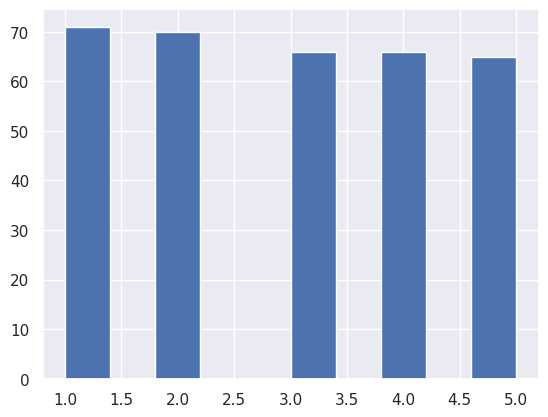

In [56]:
plt.hist(db["M"])

Мин разного вида в датасете примерно равное количество, это хорошо.

(array([ 45., 123.,  62.,  42.,  19.,  10.,   7.,   4.,   5.,  21.]),
 array([0.19773388, 0.27796036, 0.35818685, 0.43841333, 0.51863982,
        0.5988663 , 0.67909279, 0.75931927, 0.83954576, 0.91977224,
        0.99999873]),
 <BarContainer object of 10 artists>)

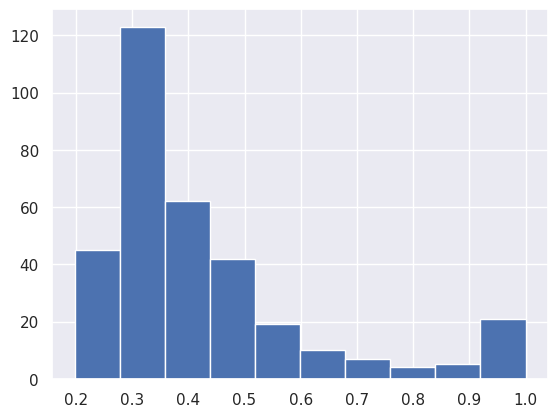

In [58]:
plt.hist(db["V"])

In [ ]:
ЗАметно, что датчик выдает чаще напряжение около 0,3 (нормализованное)

(array([49., 30., 28., 29., 29., 30., 30., 29., 29., 55.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

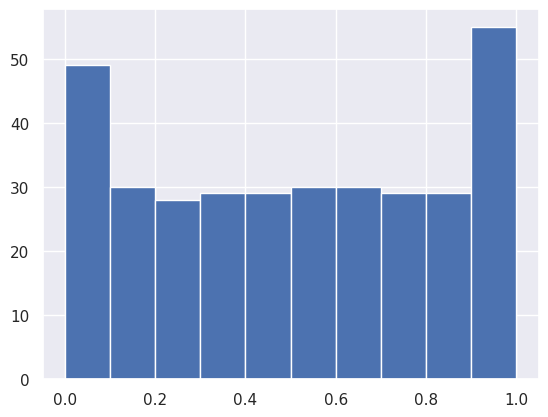

In [59]:
plt.hist(db["H"])

Металлоискатель держали на случайном расстоянии от земли.

(array([59.,  0., 51.,  0., 56., 57.,  0.,  0., 58., 57.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

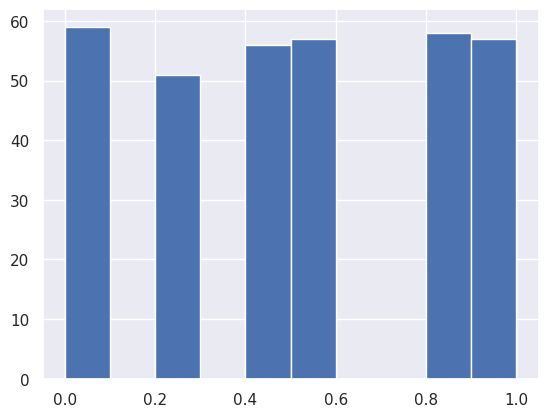

In [60]:
plt.hist(db["S"])

Дискретное деление на виды почв (6), тоже нормализованное.
Построим графики возможной взаимосвязи фич с типом мины.

<Axes: xlabel='V_category', ylabel='count'>

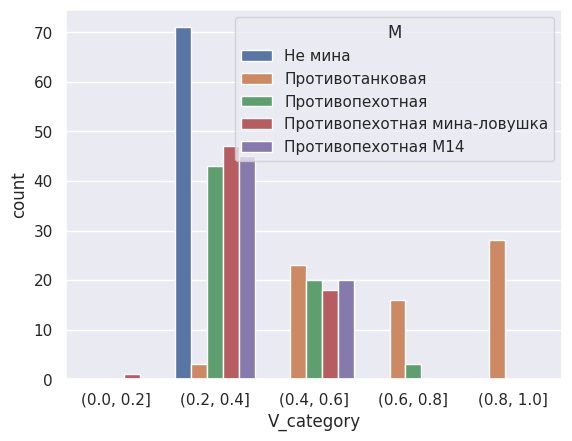

In [73]:
db_2["V_category"] = pd.cut(x=db_2["V"], bins=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
sns.countplot(data=db_2, x="V_category", hue='M')

Видно, что если напряжение на сенсоре выше 0,8 нормализованной единицы, то это точно противотанковая мина, а если не в интервале 0,2 - 0,4, то хоть какая-то мина там есть.

<Axes: xlabel='H_category', ylabel='count'>

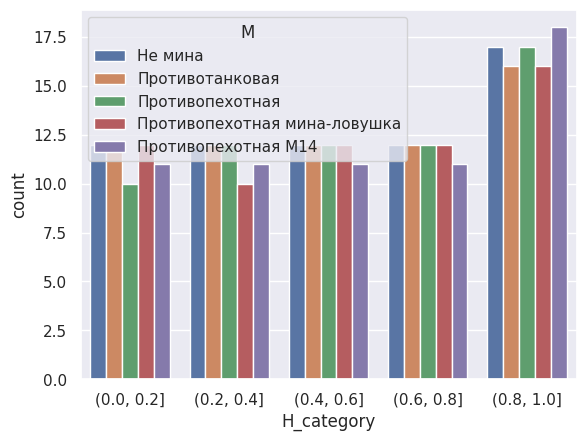

In [75]:
db_2["H_category"] = pd.cut(x=db_2["H"], bins=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
sns.countplot(data=db_2, x="H_category", hue='M')

Видно, что тип мины от высоты от искателя до земли не зависит, что логично.

<Axes: xlabel='S', ylabel='count'>

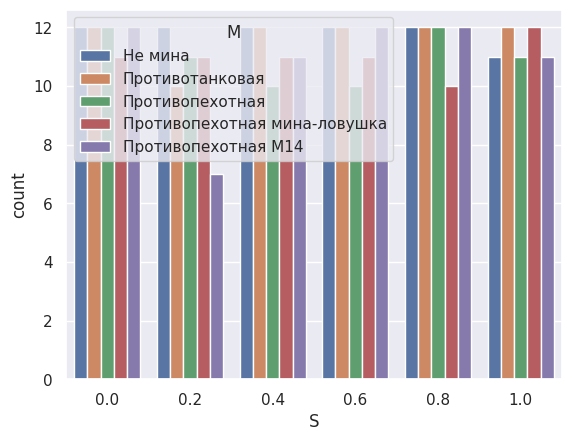

In [76]:
sns.countplot(data=db_2, x="S", hue='M')

От типа почвы тип мины зависит тоже слабо.

Построим три групповые диаграммы. 1)

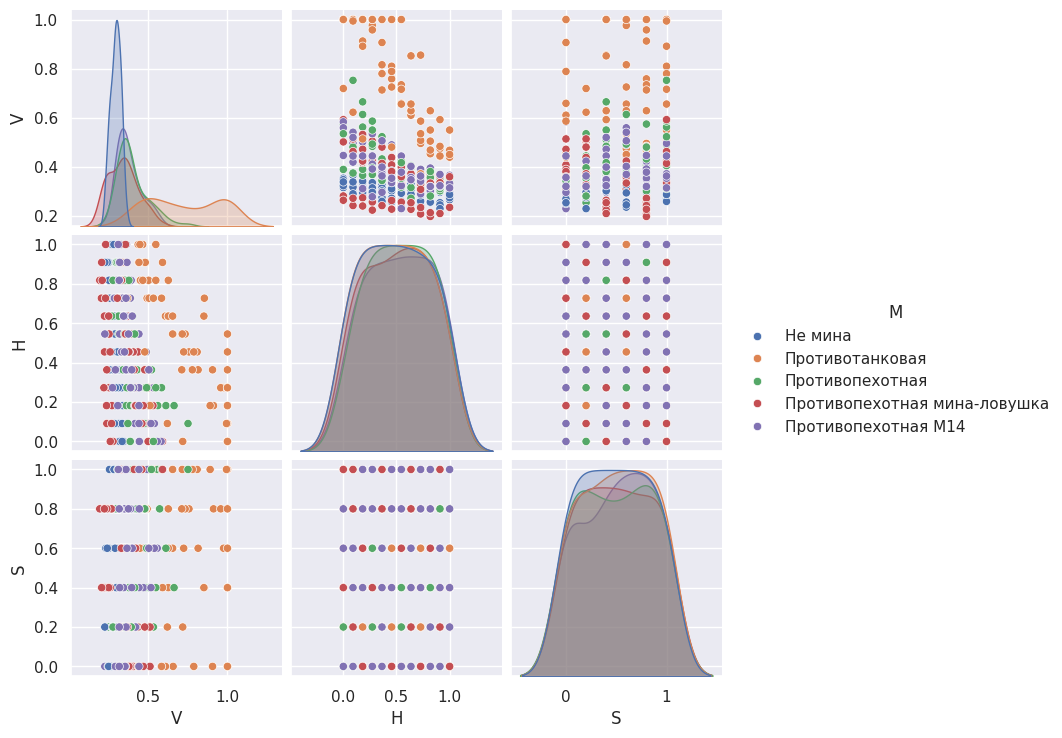

In [79]:
sns.pairplot(db_2, kind="scatter", hue="M");

Видно, например, на втором в верхней строке графике, что для обнаружения противотанковой мины с увеличением высоты от детектора до почвы напряжение на сенсоре может падать.

2)

<Axes: >

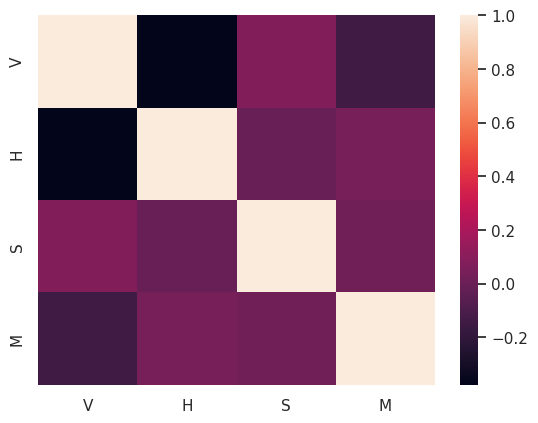

In [80]:
sns.heatmap(db.corr(numeric_only = True))

Видно, что напряжение с сенсора от высоты зависит обратно, а от типа почвы - прямо.

3)

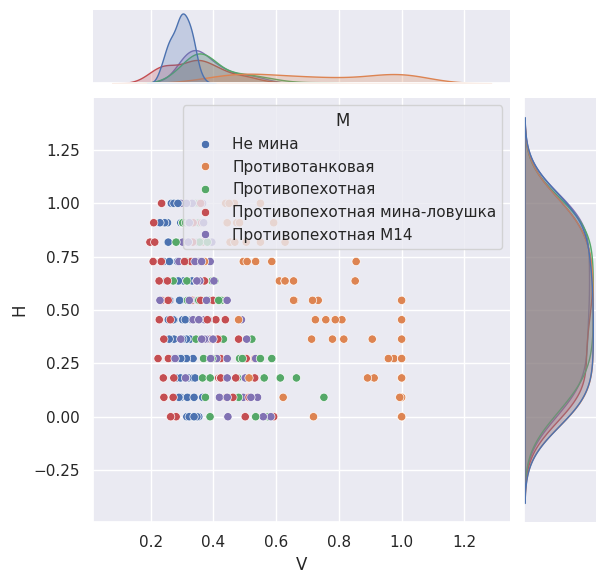

In [83]:
sns.jointplot(
    x = "V",
    y = "H",
    hue = "M",
    data = db_2);

РАспределение типов мин по расстояниям от земли и напряжениями на сенсоре. Противотанковые мины снова выделяются.

Задание выполнено, по результатам задания получены навыки предварительной обработки и визуализации данных перед построением моделей искусственного интеллекта на их основе.